C:\Users\Desktop\AppData\Roaming\Python\Python39\site-packages\platipy\imaging\dose\dvh.py:102: RuntimeWarning: Mean of empty slice.
  mean_dose = dose_array[mask_array > 0].mean()
c:\Users\Desktop\anaconda3\envs\btcv_copy\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Desktop\anaconda3\envs\btcv_copy\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


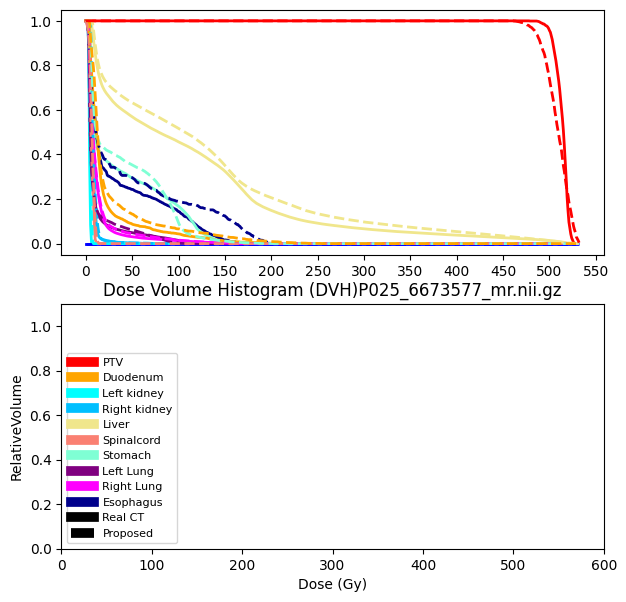

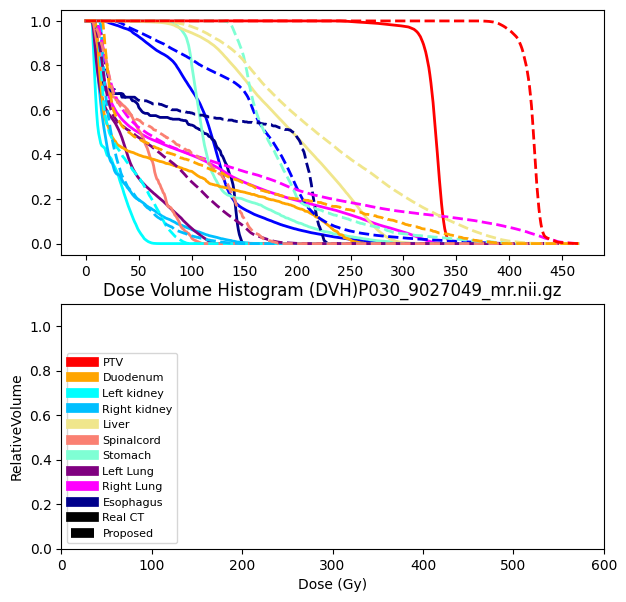

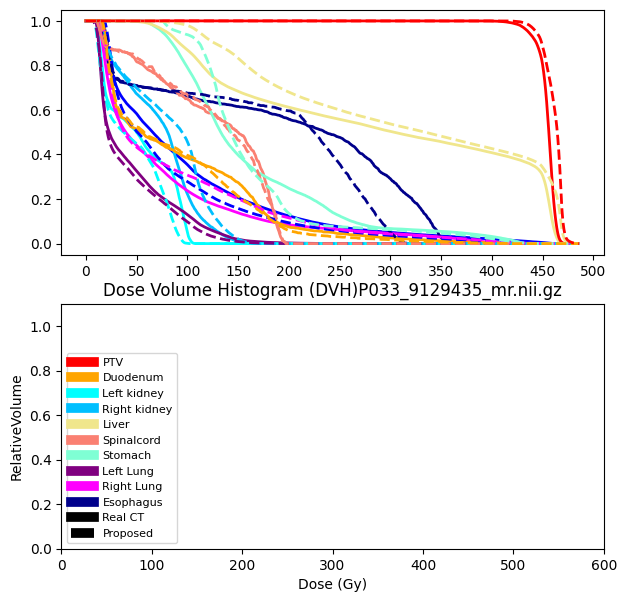

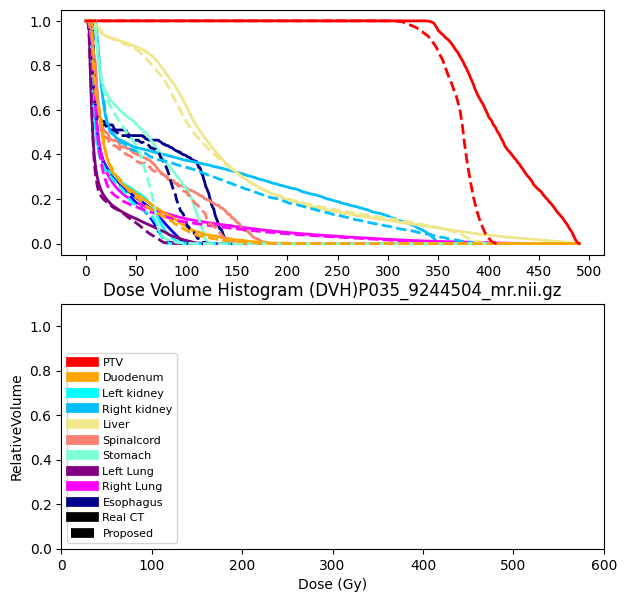

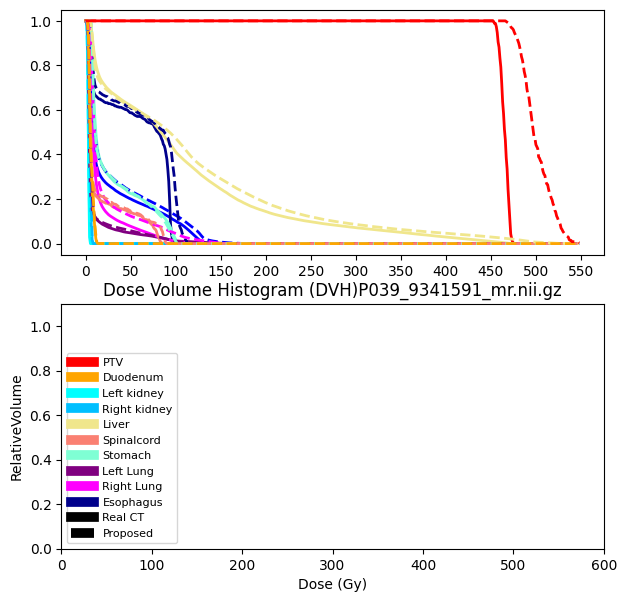

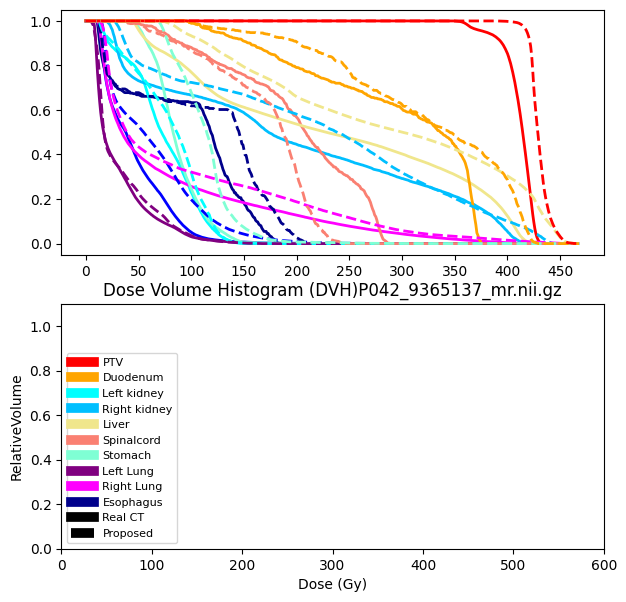

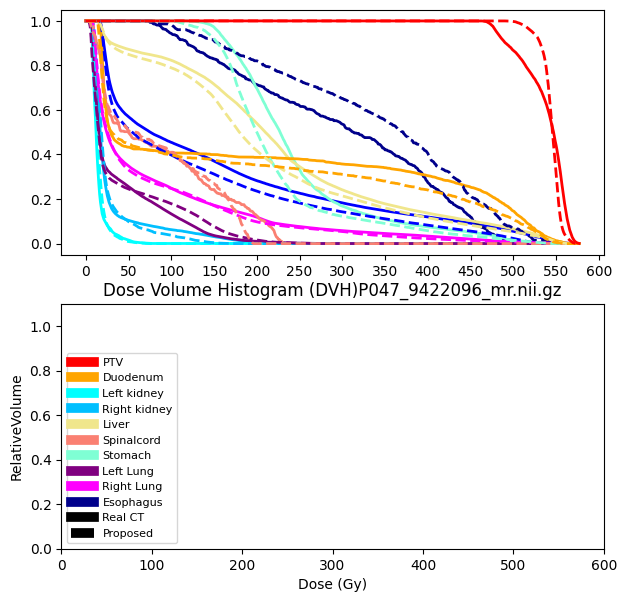

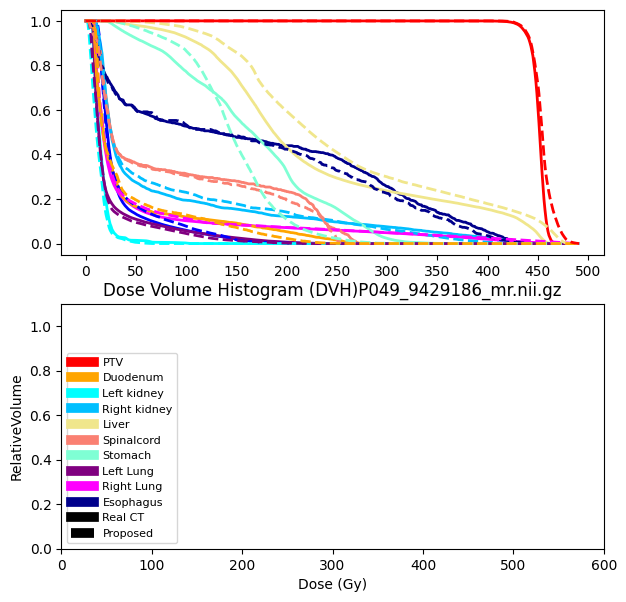

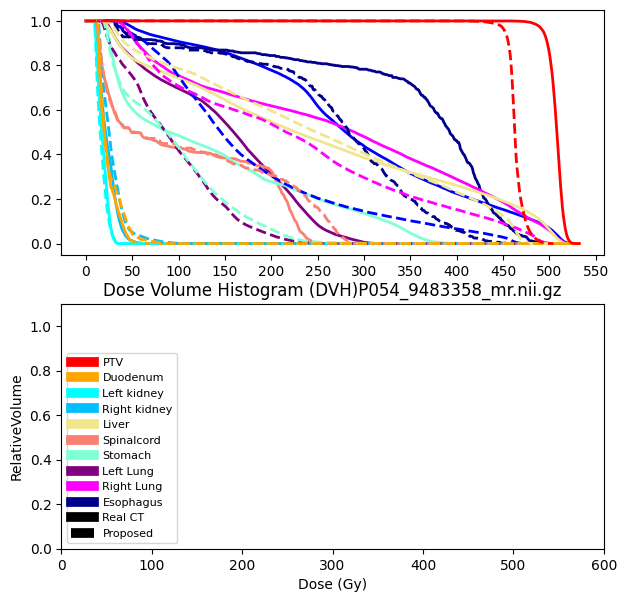

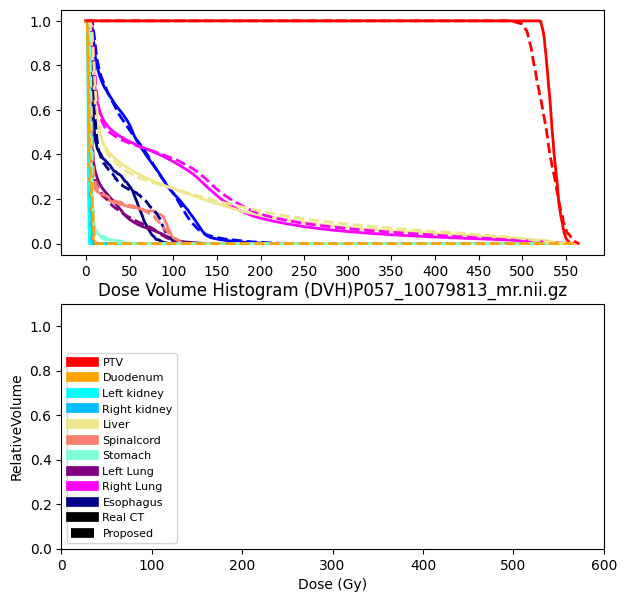

In [1]:
import os 
import matplotlib
import SimpleITK as sitk 
import numpy as np
from platipy.imaging.tests.data import get_hn_nifti
from platipy.imaging import ImageVisualiser
from platipy.imaging.label.utils import get_com
from platipy.imaging.dose.dvh import calculate_dvh_for_labels, calculate_d_x, calculate_v_x
from platipy.imaging.visualisation.dose import visualise_dose
import matplotlib.pyplot as plt 
pred_basepath = r"X:\!project\!2025_doseprediction\results\exp15_ensemble_ver"
pred_dirs_list= os.listdir(pred_basepath)
gt_basepath = r"X:\!project\!2025_doseprediction\data\gt_data_2\dose"
gt_dirs_list = os.listdir(gt_basepath)
mr_basepath = r"X:\!project\!2025_doseprediction\data\gt_data_2\mr"
mr_dirs_list = os.listdir(mr_basepath)
oar_basepath = r"X:\!project\!2025_doseprediction\data\gt_data_2\oar"
# oar_dirs_list = os.listdir(oar_basepath)
ptv_basepath = r"X:\!project\!2025_doseprediction\data\gt_data_2\hptv"
ptv_dirs_list = os.listdir(ptv_basepath)
lptv_basepath = r"X:\!project\!2025_doseprediction\data\gt_data_2\lptv"
lptv_dirs_list = sorted(os.listdir(lptv_basepath))


for mr_dir, gt_dir, pr_dir, ptv_dir, lptv_dir in zip(mr_dirs_list, gt_dirs_list, pred_dirs_list, ptv_dirs_list, lptv_dirs_list):
    structs_dict = {"heart" : None, 
                     "esophagus" : None, 
                     "kidney_l" : None, 
                     "kidney_r" : None, 
                     "lung_l" : None, 
                     "lung_r" : None,
                     "spinalcord" : None,
                     "stomach" : None,
                     "liver" : None,
                     "duodenum" : None,
                     "PTV" : None
                     }
    pnum = mr_dir.split("_")[0]
    mrn = mr_dir.split("_")[1]
    
    gt_itk = sitk.ReadImage(os.path.join(gt_basepath, gt_dir))
    pr_itk = sitk.ReadImage(os.path.join(pred_basepath, pr_dir))
    pr_arr = sitk.GetArrayFromImage(pr_itk)
    pr_arr[pr_arr < 0] = 0
    pr_itk = sitk.GetImageFromArray(pr_arr)
    for key in structs_dict.keys():
        if key == "PTV":
            continue 
        structs_dict[key] = sitk.ReadImage(os.path.join(oar_basepath, f"{pnum}_{mrn}_{key}.nii.gz"))
    ptv_itk = sitk.ReadImage(os.path.join(ptv_basepath, ptv_dir))
    lptv_itk = sitk.ReadImage(os.path.join(lptv_basepath, lptv_dir))
    ptv_arr = sitk.GetArrayFromImage(ptv_itk)
    lptv_arr = sitk.GetArrayFromImage(lptv_itk)
    
    # ptv_arr += lptv_arr 
    ptv_itk = sitk.GetImageFromArray(ptv_arr)
    ptv_itk.CopyInformation(lptv_itk)
    structs_dict["PTV"] = ptv_itk

    pr_itk.SetOrigin(gt_itk.GetOrigin())
    pr_itk.SetSpacing(gt_itk.GetSpacing())
    pr_itk.SetDirection(gt_itk.GetDirection())
    dvh_gt = calculate_dvh_for_labels(gt_itk, structs_dict)
    dvh_pr = calculate_dvh_for_labels(pr_itk, structs_dict)
    dvh_list = [dvh_gt, dvh_pr]
    line_list = ["solid", "dashed"]
    fig, ax = plt.subplots(nrows=2, ncols =1, figsize =(7, 7))
    for i, dvh in enumerate(dvh_list):

        plt_dvh = dvh
        # plt_dvh = plt_dvh.set_index("label")
        plt_dvh = plt_dvh.iloc[:,3:].transpose()
        
        # Plot the DVH
        ax[0].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax[0].set_xticks([i * 50 for i in range(14)])
        # plt_dvh.plot(ax=ax[i], kind="line", colormap=matplotlib.colormaps.get_cmap("rainbow"), legend=False)
        # if i == 0:
        #     plt_dvh.plot(ax=ax, kind="line", linestyle = line_list[i], colormap=matplotlib.colormaps.get_cmap("rainbow"), legend=True)
            
        # else:
        #     plt_dvh.plot(ax=ax, kind="line", linestyle = line_list[i], colormap=matplotlib.colormaps.get_cmap("rainbow"))
        #     ax.get_legend().remove()
        plot_dvh_list = [np.squeeze(np.array(plt_dvh[j])) for j in range(11)]
        
        color_list = ["blue","darkblue", "cyan", "deepskyblue", "purple", "magenta","salmon", "aquamarine", "khaki", "orange", "red"]
        
        for j in range(len(plot_dvh_list)):
           
            ax[0].plot(plot_dvh_list[j], linestyle = line_list[i], linewidth=2, color=color_list[j])
        gtv_line = plt.Line2D([], [], linewidth=7,color='red', linestyle='-', label='PTV')
        duodenum_line = plt.Line2D([], [], linewidth=7,color='orange', linestyle='-', label='Duodenum')
        kidney_l_line = plt.Line2D([], [], linewidth=7,color='cyan', linestyle='-', label='Left kidney')
        kidney_r_line = plt.Line2D([], [], linewidth=7,color='deepskyblue', linestyle='-', label='Right kidney')
        liver_line = plt.Line2D([], [], linewidth=7,color='khaki', linestyle='-', label='Liver')
        spinalcord_line = plt.Line2D([], [], linewidth=7,color='salmon', linestyle='-', label='Spinalcord')
        stomach_line = plt.Line2D([], [], linewidth=7,color='aquamarine', linestyle='-', label='Stomach')
        lung_l_line = plt.Line2D([], [], linewidth=7,color='purple', linestyle='-', label='Left Lung')
        lung_r_line = plt.Line2D([], [], linewidth=7,color='magenta', linestyle='-', label='Right Lung')
        esophagus_line = plt.Line2D([], [], linewidth=7,color='darkblue', linestyle='-', label='Esophagus')
        ref_line = plt.Line2D([], [], linestyle='solid', linewidth=7,color="black", label='Real CT')
        prop_line = plt.Line2D([], [], linestyle='dashed',linewidth=7,color="black", label='Proposed')
        ax[1].legend(handles=[gtv_line, duodenum_line, kidney_l_line, kidney_r_line, liver_line, spinalcord_line, stomach_line, lung_l_line, lung_r_line, esophagus_line, ref_line, prop_line], loc='lower left', prop={"size":8})
        # Add labels and show plot
    # fig.get_legend().remove()
    # plt.legend(loc='best')
    plt.xlabel("Dose (Gy)")
    plt.ylabel("RelativeVolume")
    plt.ylim(0, 1.1)
    plt.xlim(0, 600)
    
    plt.title("Dose Volume Histogram (DVH)" + mr_dir)
    plt.show()